# **Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
pd.set_option("display.max_Columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("Nassau Candy Distributor.csv")
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 10194
Columns: 18


In [3]:
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [5]:
print("Columns in the dataset:\n")
for i, column in enumerate(df.columns, start=1):
  print(i, ":", column)

Columns in the dataset:

1 : Row ID
2 : Order ID
3 : Order Date
4 : Ship Date
5 : Ship Mode
6 : Customer ID
7 : Country/Region
8 : City
9 : State/Province
10 : Postal Code
11 : Division
12 : Region
13 : Product ID
14 : Product Name
15 : Sales
16 : Units
17 : Gross Profit
18 : Cost


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing.sort_values(
    "Missing Values",
    ascending=False
)
display(missing)

,Missing Values,Missing %
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Country/Region,0,0.0
City,0,0.0
State/Province,0,0.0
Postal Code,0,0.0


In [7]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,10194.0,NaN,NaN,NaN,5097.5,2942.898656,1.0,2549.25,5097.5,7645.75,10194.0
Order ID,10194,8549,US-2022-130974-CHO-SCR-58000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,717,02-09-2025,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,10194,1338,07-06-2028,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194.0,NaN,NaN,NaN,134468.961154,20231.483007,100006.0,117212.0,133550.0,152051.0,192314.0
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State/Province,10194,59,California,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,10194,654,10035,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)
df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True,
    errors="coerce"
)
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [10]:
df["Shipping Lead Time"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days
display(
    df[
        [
            "Order Date",
            "Ship Date",
            "Shipping Lead Time"
        ]
    ].head(10)
)

,Order Date,Ship Date,Shipping Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


In [11]:
print("Minimum lead time:",
      df["Shipping Lead Time"].min())

print("Maximum lead time:",
      df["Shipping Lead Time"].max())

print("Average lead time:",
      df["Shipping Lead Time"].mean())

print("Median lead time:",
      df["Shipping Lead Time"].median())

Minimum lead time: 904
Maximum lead time: 1642
Average lead time: 1320.8418677653522
Median lead time: 1274.0


In [12]:
df.shape

(10194, 19)

In [13]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost',
 'Shipping Lead Time']

In [14]:
df[["Order Date", "Ship Date", "Shipping Lead Time"]].head(10)

,Order Date,Ship Date,Shipping Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


In [15]:
df["Shipping Lead Time"].describe()

,Shipping Lead Time
count,10194.000000
mean,1320.841868
std,262.444892
min,904.000000
25%,1271.000000
50%,1274.000000
75%,1638.000000
max,1642.000000


# **Data Quality Investigation**

In [16]:
print("Order Date Range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date Range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

Order Date Range:
2024-01-02 00:00:00 to 2025-12-31 00:00:00

Ship Date Range:
2026-06-30 00:00:00 to 2030-06-28 00:00:00


In [17]:
print("Records with negative lead time:")
display(
    df[df["Shipping Lead Time"] < 0][
        [
            "Order ID",
            "Order Date",
            "Ship Date",
            "Shipping Lead Time"
        ]
    ].head(20)
)

Records with negative lead time:


,Order ID,Order Date,Ship Date,Shipping Lead Time


In [18]:
print("Records with lead time greater than 365 days:")

display(
    df[df["Shipping Lead Time"] > 365][
        [
            "Order ID",
            "Order Date",
            "Ship Date",
            "Shipping Lead Time"
        ]
    ].head(20)
)

Records with lead time greater than 365 days:


,Order ID,Order Date,Ship Date,Shipping Lead Time
0,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,909
1,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,909
2,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,909
3,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,909
4,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,912
5,US-2021-167199-CHO-SCR-58000,2024-01-06,2026-07-03,909
6,US-2021-167199-CHO-TRI-54000,2024-01-06,2026-07-03,909
7,US-2021-106054-CHO-MIL-31000,2024-01-06,2026-06-30,906
8,US-2021-167199-CHO-NUT-13000,2024-01-06,2026-07-03,909
9,US-2021-167199-CHO-MIL-31000,2024-01-06,2026-07-03,909


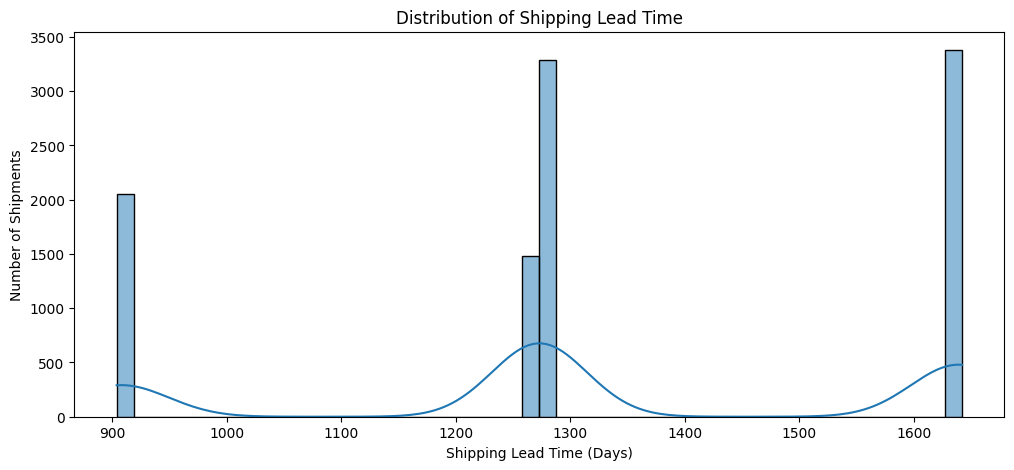

In [19]:
plt.figure(figsize=(12, 5))

sns.histplot(
    df["Shipping Lead Time"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Shipping Lead Time")
plt.xlabel("Shipping Lead Time (Days)")
plt.ylabel("Number of Shipments")

plt.show()

In [20]:
lead_time_counts = (
    df["Shipping Lead Time"]
    .value_counts()
    .sort_index()
)

display(
    lead_time_counts.head(30)
)

,count
Shipping Lead Time,
904,89
905,40
906,289
907,176
908,591
909,519
910,207
911,134
912,4


In [21]:
suspicious = df[
    df["Shipping Lead Time"] > 365
].copy()

print("Number of records with lead time > 365 days:",
      len(suspicious))

display(
    suspicious[
        [
            "Order ID",
            "Order Date",
            "Ship Date",
            "Ship Mode",
            "Product Name",
            "Region",
            "State/Province",
            "Shipping Lead Time"
        ]
    ].head(30)
)

Number of records with lead time > 365 days: 10194


,Order ID,Order Date,Ship Date,Ship Mode,Product Name,Region,State/Province,Shipping Lead Time
0,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,Wonka Bar - Milk Chocolate,Interior,Texas,909
1,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,Wonka Bar - Triple Dazzle Caramel,Interior,Illinois,909
2,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,Wonka Bar - Nutty Crunch Surprise,Interior,Illinois,909
3,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,Wonka Bar -Scrumdiddlyumptious,Interior,Illinois,909
4,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,Wonka Bar - Triple Dazzle Caramel,Atlantic,Pennsylvania,912
5,US-2021-167199-CHO-SCR-58000,2024-01-06,2026-07-03,Standard Class,Wonka Bar -Scrumdiddlyumptious,Gulf,Kentucky,909
6,US-2021-167199-CHO-TRI-54000,2024-01-06,2026-07-03,Standard Class,Wonka Bar - Triple Dazzle Caramel,Gulf,Kentucky,909
7,US-2021-106054-CHO-MIL-31000,2024-01-06,2026-06-30,First Class,Wonka Bar - Milk Chocolate,Gulf,Georgia,906
8,US-2021-167199-CHO-NUT-13000,2024-01-06,2026-07-03,Standard Class,Wonka Bar - Nutty Crunch Surprise,Gulf,Kentucky,909
9,US-2021-167199-CHO-MIL-31000,2024-01-06,2026-07-03,Standard Class,Wonka Bar - Milk Chocolate,Gulf,Kentucky,909


# **Investigate the date pattern**

## **Order year vs Ship year**

In [22]:
year_check = pd.crosstab(
    df["Order Date"].dt.year,
    df["Ship Date"].dt.year
)

display(year_check)

Ship Date,2026,2027,2028,2029,2030
Order Date,,,,,
2024,711,2089,1381,0,0
2025,0,0,986,2899,2128


In [23]:
lead_time_stats = df["Shipping Lead Time"].describe()
display(lead_time_stats)

,Shipping Lead Time
count,10194.000000
mean,1320.841868
std,262.444892
min,904.000000
25%,1271.000000
50%,1274.000000
75%,1638.000000
max,1642.000000


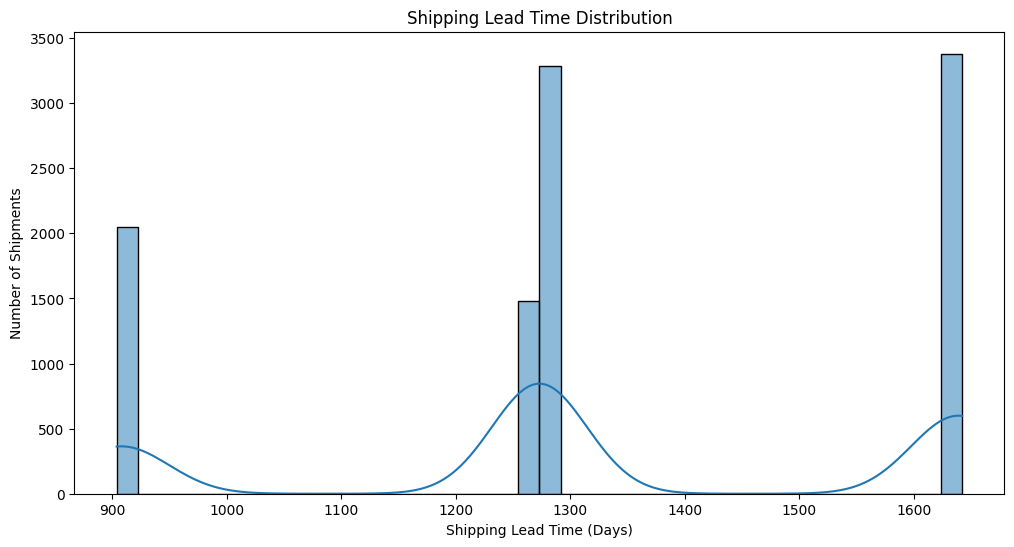

In [24]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Shipping Lead Time",
    bins=40,
    kde=True
)

plt.title("Shipping Lead Time Distribution")
plt.xlabel("Shipping Lead Time (Days)")
plt.ylabel("Number of Shipments")

plt.show()

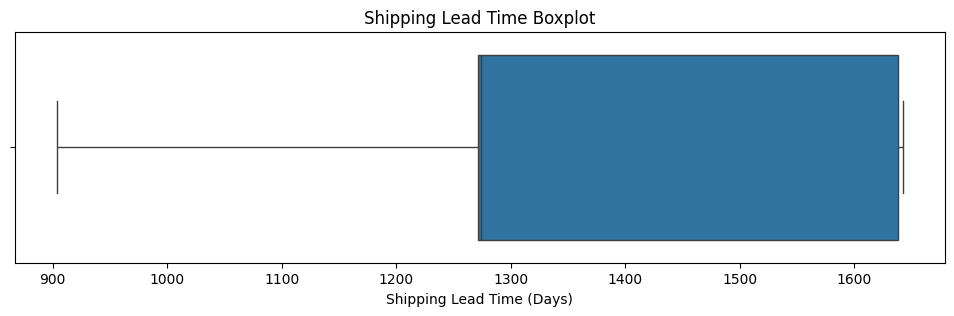

In [25]:
plt.figure(figsize=(12, 3))

sns.boxplot(
    x=df["Shipping Lead Time"]
)

plt.title("Shipping Lead Time Boxplot")
plt.xlabel("Shipping Lead Time (Days)")

plt.show()

# **Creation of data quality flag**

In [26]:
df["Lead Time Quality Flag"] = np.where(
    df["Shipping Lead Time"] > 365,
    "Review - >365 days",
    "Normal"
)

In [27]:
display(
    df["Lead Time Quality Flag"].value_counts()
)

,count
Lead Time Quality Flag,
Review - >365 days,10194


# **Creation of factory mapping**

In [28]:
PRODUCT_FACTORY_MAP = {

    # Chocolate
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O Nuts",

    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",

    # Sugar
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",

    # Other
    "Fizzy Lifting Drinks": "Sugar Shack",

    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",

    "Hair Toffee": "The Other Factory",
    "Kazookles": "The Other Factory"
}

In [29]:
df["Factory"] = df["Product Name"].map(
    PRODUCT_FACTORY_MAP
)

df["Factory"] = df["Factory"].fillna(
    "Unknown Factory"
)

display(
    df[
        [
            "Product Name",
            "Factory"
        ]
    ].drop_duplicates()
)

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O Nuts
13,Wonka Bar - Fudge Mallows,Lot's O Nuts
19,Wonka Gum,Secret Factory
26,Kazookles,The Other Factory
136,Lickable Wallpaper,Secret Factory
191,Fizzy Lifting Drinks,Sugar Shack
226,Laffy Taffy,Sugar Shack


In [30]:
print("Factory distribution:")

display(
    df["Factory"].value_counts()
)

Factory distribution:


,count
Factory,
Lot's O Nuts,5692
Wicked Choccy's,4152
Secret Factory,217
The Other Factory,100
Sugar Shack,33


In [31]:
print("Products without a factory mapping:")

display(
    df[
        df["Factory"] == "Unknown Factory"
    ][
        ["Product Name"]
    ].drop_duplicates()
)

Products without a factory mapping:


,Product Name


In [32]:
df["Factory → Region"] = (
    df["Factory"]
    + " → "
    + df["Region"].astype(str)
)

df["Factory → State"] = (
    df["Factory"]
    + " → "
    + df["State/Province"].astype(str)
)

In [33]:
display(
    df[
        [
            "Product Name",
            "Factory",
            "Region",
            "State/Province",
            "Factory → Region",
            "Factory → State"
        ]
    ].head(10)
)

,Product Name,Factory,Region,State/Province,Factory → Region,Factory → State
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Texas,Wicked Choccy's → Interior,Wicked Choccy's → Texas
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Illinois,Wicked Choccy's → Interior,Wicked Choccy's → Illinois
2,Wonka Bar - Nutty Crunch Surprise,Lot's O Nuts,Interior,Illinois,Lot's O Nuts → Interior,Lot's O Nuts → Illinois
3,Wonka Bar -Scrumdiddlyumptious,Lot's O Nuts,Interior,Illinois,Lot's O Nuts → Interior,Lot's O Nuts → Illinois
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Pennsylvania,Wicked Choccy's → Atlantic,Wicked Choccy's → Pennsylvania
5,Wonka Bar -Scrumdiddlyumptious,Lot's O Nuts,Gulf,Kentucky,Lot's O Nuts → Gulf,Lot's O Nuts → Kentucky
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Gulf,Kentucky,Wicked Choccy's → Gulf,Wicked Choccy's → Kentucky
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,Gulf,Georgia,Wicked Choccy's → Gulf,Wicked Choccy's → Georgia
8,Wonka Bar - Nutty Crunch Surprise,Lot's O Nuts,Gulf,Kentucky,Lot's O Nuts → Gulf,Lot's O Nuts → Kentucky
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,Gulf,Kentucky,Wicked Choccy's → Gulf,Wicked Choccy's → Kentucky


In [34]:
df["Profit Margin %"] = np.where(
    df["Sales"] != 0,
    (df["Gross Profit"] / df["Sales"]) * 100,
    0
)

In [35]:
df["Cost per Unit"] = np.where(
    df["Units"] != 0,
    df["Cost"] / df["Units"],
    0
)

In [36]:
print("Final dataset shape:", df.shape)

display(df.head())

print("\nMissing values:")
display(
    df.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

Final dataset shape: (10194, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Lead Time Quality Flag,Factory,Factory → Region,Factory → State,Profit Margin %,Cost per Unit
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,Review - >365 days,Wicked Choccy's,Wicked Choccy's → Interior,Wicked Choccy's → Texas,64.923077,1.14
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,Review - >365 days,Wicked Choccy's,Wicked Choccy's → Interior,Wicked Choccy's → Illinois,65.333333,1.30
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,Review - >365 days,Lot's O Nuts,Lot's O Nuts → Interior,Lot's O Nuts → Illinois,71.346705,1.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,Review - >365 days,Lot's O Nuts,Lot's O Nuts → Interior,Lot's O Nuts → Illinois,69.444444,1.10
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,Review - >365 days,Wicked Choccy's,Wicked Choccy's → Atlantic,Wicked Choccy's → Pennsylvania,65.333333,1.30



Missing values:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


# **Stage 2 : Exploratory Data Analysis**

In [37]:
total_records = len(df)

unique_orders = df["Order ID"].nunique()

total_sales = df["Sales"].sum()

total_units = df["Units"].sum()

total_cost = df["Cost"].sum()

total_profit = df["Gross Profit"].sum()

profit_margin = (
    total_profit / total_sales * 100
    if total_sales != 0
    else 0
)
average_order_value = (
    total_sales / unique_orders
    if unique_orders != 0
    else 0
)
print("========== BUSINESS KPIs ==========")

print(f"Total shipment records : {total_records:,}")
print(f"Unique orders          : {unique_orders:,}")
print(f"Total units            : {total_units:,.0f}")
print(f"Total sales            : ${total_sales:,.2f}")
print(f"Total cost             : ${total_cost:,.2f}")
print(f"Total gross profit     : ${total_profit:,.2f}")
print(f"Profit margin          : {profit_margin:.2f}%")
print(f"Average order value    : ${average_order_value:,.2f}")

========== BUSINESS KPIs ==========
Total shipment records : 10,194
Unique orders          : 8,549
Total units            : 38,654
Total sales            : $141,783.63
Total cost             : $48,340.83
Total gross profit     : $93,442.80
Profit margin          : 65.91%
Average order value    : $16.58


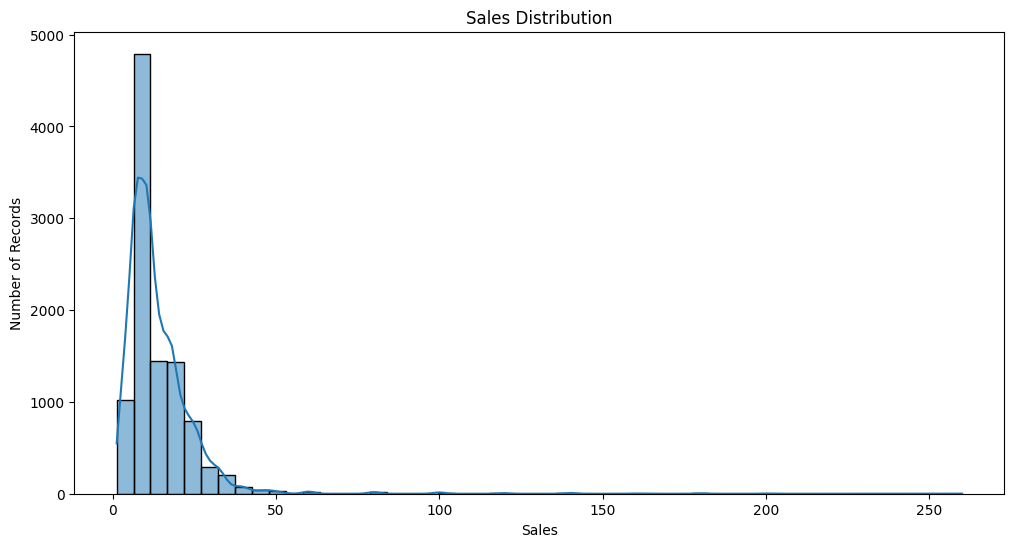

In [38]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["Sales"],
    bins=50,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Number of Records")

plt.show()

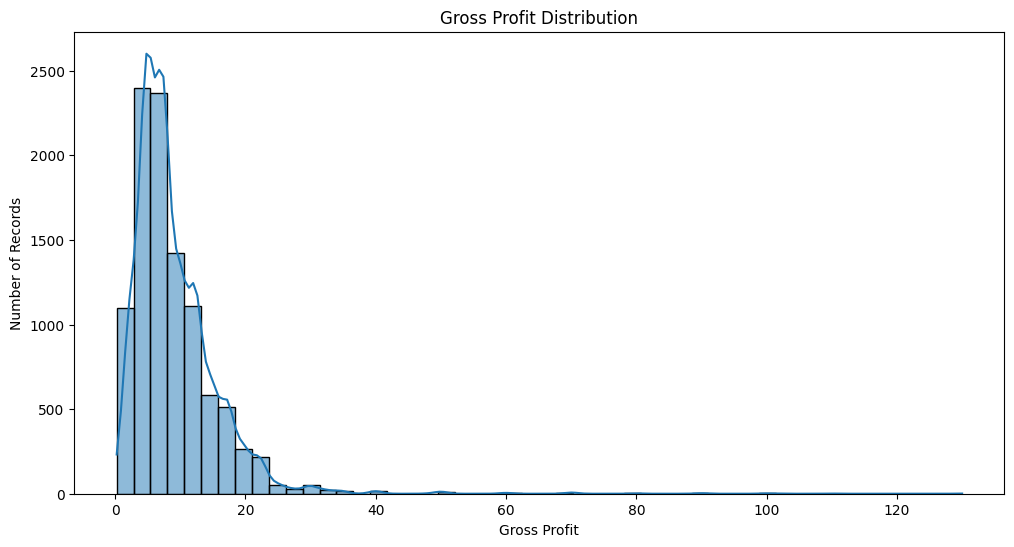

In [39]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["Gross Profit"],
    bins=50,
    kde=True
)

plt.title("Gross Profit Distribution")
plt.xlabel("Gross Profit")
plt.ylabel("Number of Records")

plt.show()

In [40]:
product_sales = (
    df.groupby("Product Name", as_index=False)
      .agg(
          Sales=("Sales", "sum"),
          Units=("Units", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .sort_values("Sales", ascending=False)
)

display(product_sales)

,Product Name,Sales,Units,Gross_Profit,Orders
12,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,1677
13,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,1704
10,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,1768
9,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,1527
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,1529
6,Lickable Wallpaper,7860.00,393,3930.00,92
4,Kazookles,1205.75,371,92.75,94
14,Wonka Gum,597.50,478,310.70,118
0,Everlasting Gobstopper,130.00,13,104.00,3
1,Fizzy Lifting Drinks,78.75,21,47.25,6


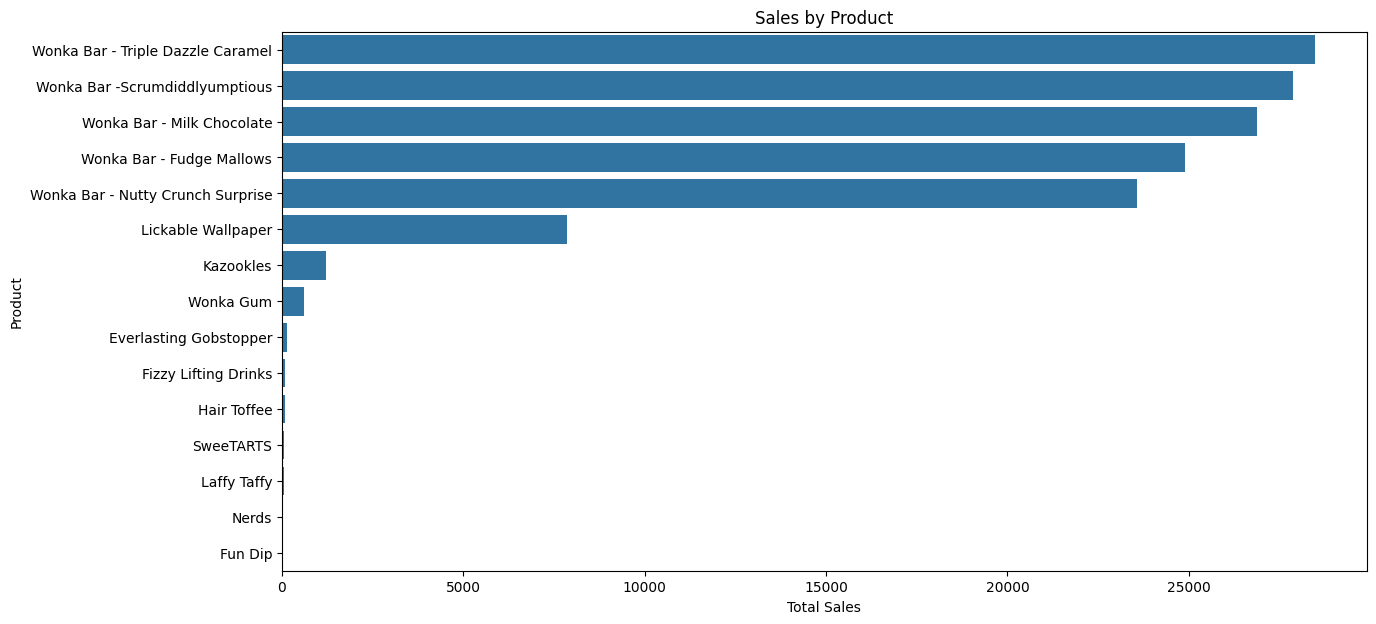

In [41]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=product_sales,
    x="Sales",
    y="Product Name"
)

plt.title("Sales by Product")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

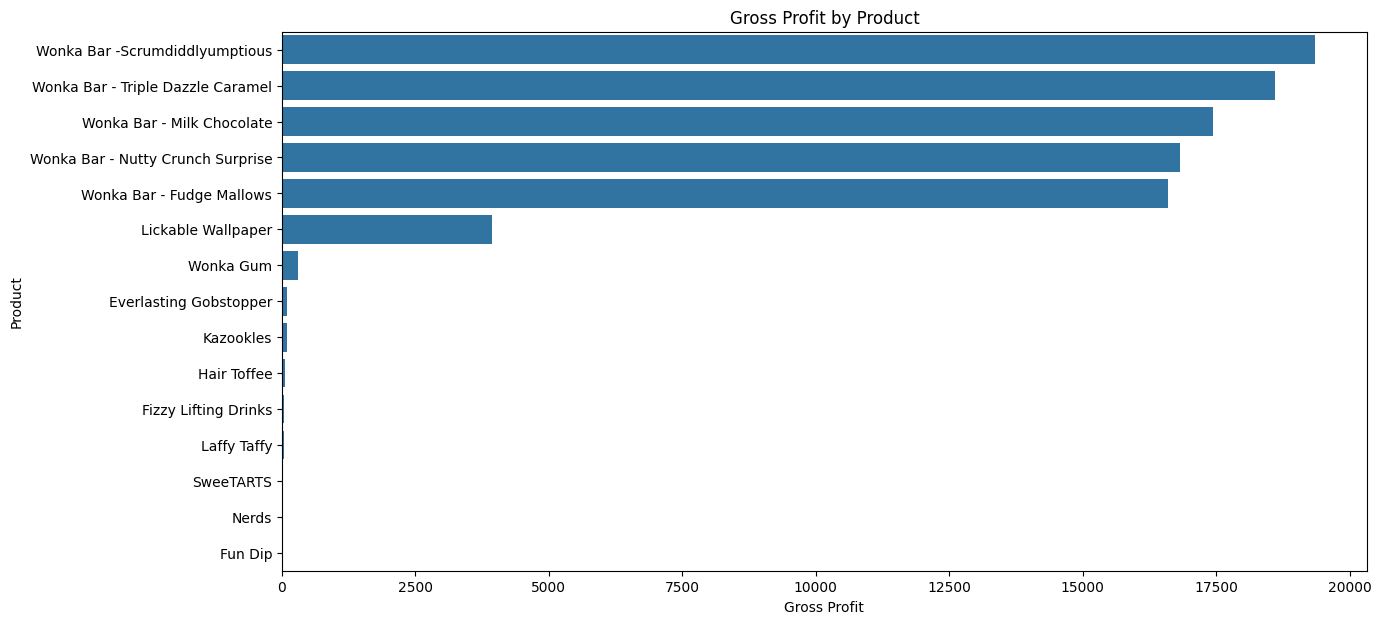

In [42]:
product_profit = (
    df.groupby("Product Name", as_index=False)
      .agg(
          Gross_Profit=("Gross Profit", "sum")
      )
      .sort_values(
          "Gross_Profit",
          ascending=False
      )
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=product_profit,
    x="Gross_Profit",
    y="Product Name"
)

plt.title("Gross Profit by Product")
plt.xlabel("Gross Profit")
plt.ylabel("Product")

plt.show()

In [43]:
factory_summary = (
    df.groupby("Factory", as_index=False)
      .agg(
          Shipments=("Order ID", "count"),
          Orders=("Order ID", "nunique"),
          Units=("Units", "sum"),
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Average_Lead_Time=("Shipping Lead Time", "mean"),
          Median_Lead_Time=("Shipping Lead Time", "median")
      )
)

factory_summary["Profit Margin %"] = (
    factory_summary["Gross_Profit"]
    /
    factory_summary["Sales"]
    * 100
)

display(
    factory_summary.sort_values(
        "Sales",
        ascending=False
    )
)

,Factory,Shipments,Orders,Units,Sales,Cost,Gross_Profit,Average_Lead_Time,Median_Lead_Time,Profit Margin %
0,Lot's O Nuts,5692,4760,21412,76340.15,23569.10,52771.05,1321.228742,1274.0,69.126207
4,Wicked Choccy's,4152,3445,15863,55352.75,19299.18,36053.57,1321.082129,1274.0,65.134198
1,Secret Factory,217,213,884,8587.50,4242.80,4344.70,1321.870968,1274.0,50.593304
3,The Other Factory,100,98,388,1282.25,1130.00,152.25,1280.280000,1273.0,11.873660
2,Sugar Shack,33,33,107,220.98,99.75,121.23,1340.030303,1274.0,54.860168


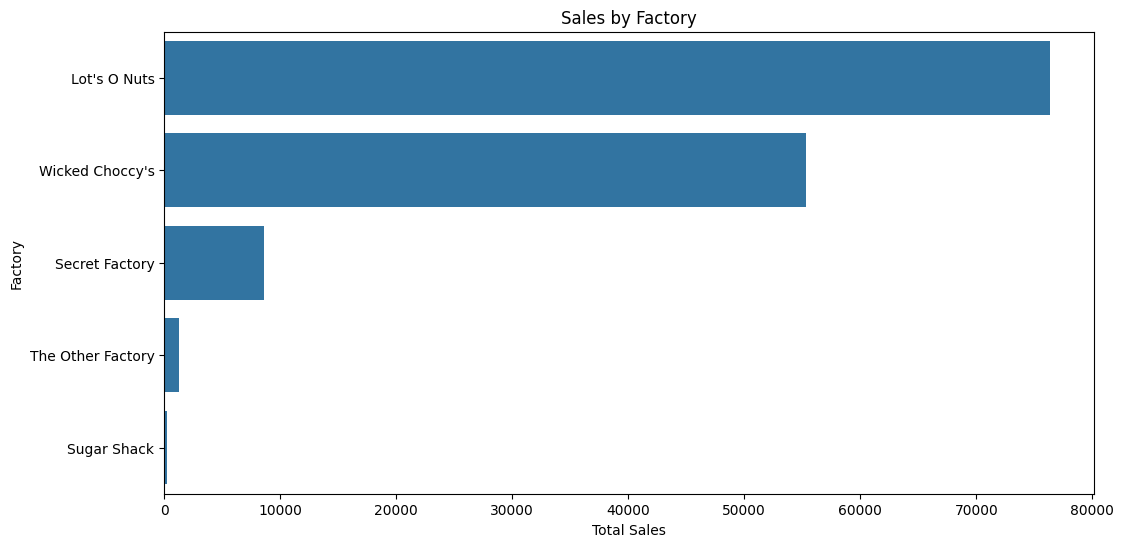

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=factory_summary.sort_values(
        "Sales",
        ascending=False
    ),
    x="Sales",
    y="Factory"
)

plt.title("Sales by Factory")
plt.xlabel("Total Sales")
plt.ylabel("Factory")

plt.show()

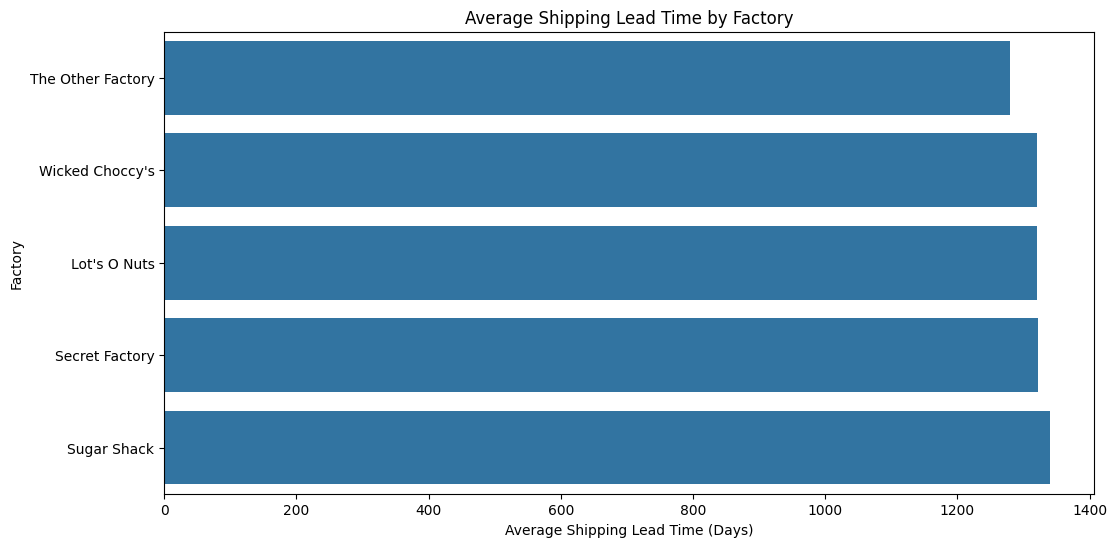

In [45]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=factory_summary.sort_values(
        "Average_Lead_Time"
    ),
    x="Average_Lead_Time",
    y="Factory"
)

plt.title(
    "Average Shipping Lead Time by Factory"
)

plt.xlabel(
    "Average Shipping Lead Time (Days)"
)

plt.ylabel("Factory")

plt.show()

In [46]:
region_summary = (
    df.groupby("Region", as_index=False)
      .agg(
          Shipments=("Order ID", "count"),
          Orders=("Order ID", "nunique"),
          Units=("Units", "sum"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Average_Lead_Time=("Shipping Lead Time", "mean")
      )
)

display(
    region_summary.sort_values(
        "Sales",
        ascending=False
    )
)

,Region,Shipments,Orders,Units,Sales,Gross_Profit,Average_Lead_Time
3,Pacific,3253,2744,12466,46301.53,30485.94,1322.194897
0,Atlantic,2986,2476,11159,41197.24,26973.70,1322.745144
2,Interior,2335,1979,8820,32037.60,21282.49,1323.091221
1,Gulf,1620,1350,6209,22247.26,14700.67,1311.374691


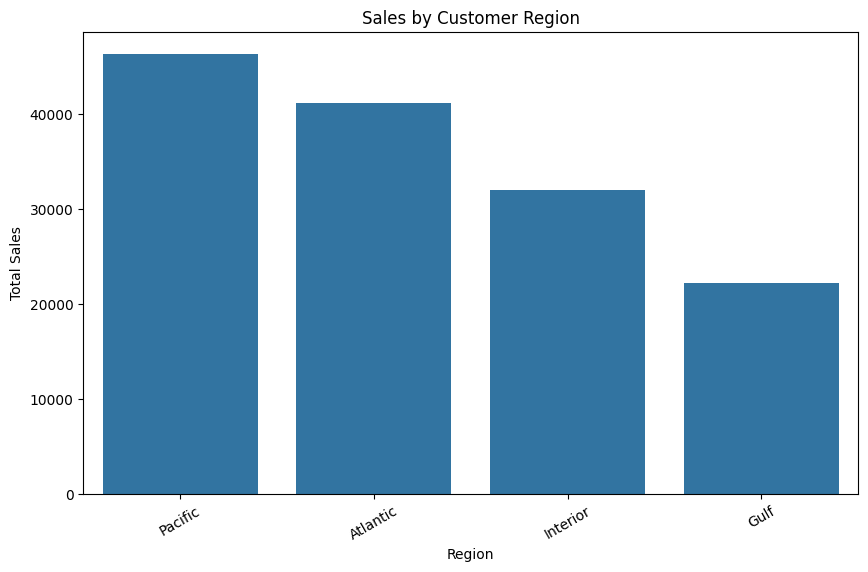

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary.sort_values(
        "Sales",
        ascending=False
    ),
    x="Region",
    y="Sales"
)

plt.title("Sales by Customer Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=30)

plt.show()

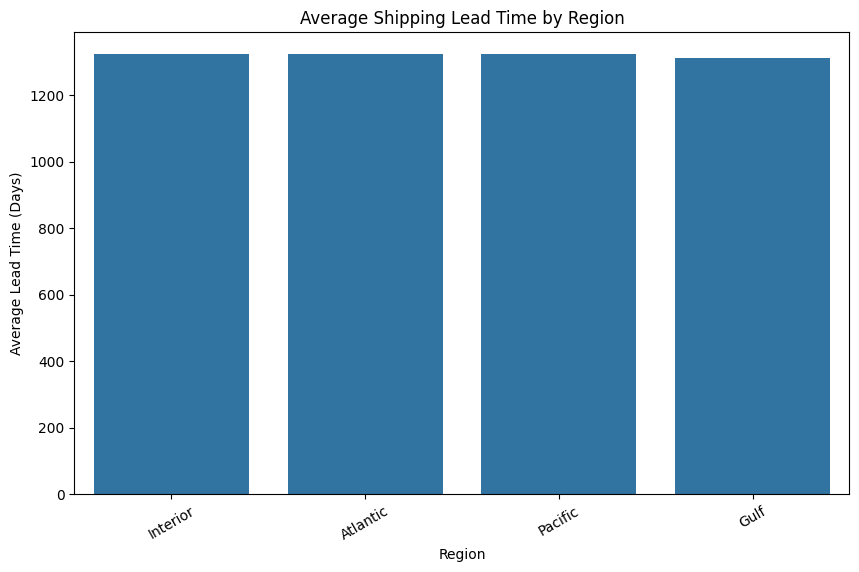

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary.sort_values(
        "Average_Lead_Time",
        ascending=False
    ),
    x="Region",
    y="Average_Lead_Time"
)

plt.title(
    "Average Shipping Lead Time by Region"
)

plt.xlabel("Region")
plt.ylabel(
    "Average Lead Time (Days)"
)

plt.xticks(rotation=30)

plt.show()

In [49]:
ship_mode_summary = (
    df.groupby("Ship Mode", as_index=False)
      .agg(
          Shipments=("Order ID", "count"),
          Orders=("Order ID", "nunique"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Cost=("Cost", "sum"),
          Average_Lead_Time=("Shipping Lead Time", "mean"),
          Median_Lead_Time=("Shipping Lead Time", "median")
      )
)

display(ship_mode_summary)

,Ship Mode,Shipments,Orders,Sales,Gross_Profit,Cost,Average_Lead_Time,Median_Lead_Time
0,First Class,1548,1312,21319.39,14011.09,7308.30,1338.275840,1272.0
1,Same Day,547,442,7113.67,4700.73,2412.94,1333.442413,1269.0
2,Second Class,1979,1653,27860.22,18306.52,9553.70,1323.845376,1273.0
3,Standard Class,6120,5142,85490.35,56424.46,29065.89,1314.334641,1274.0


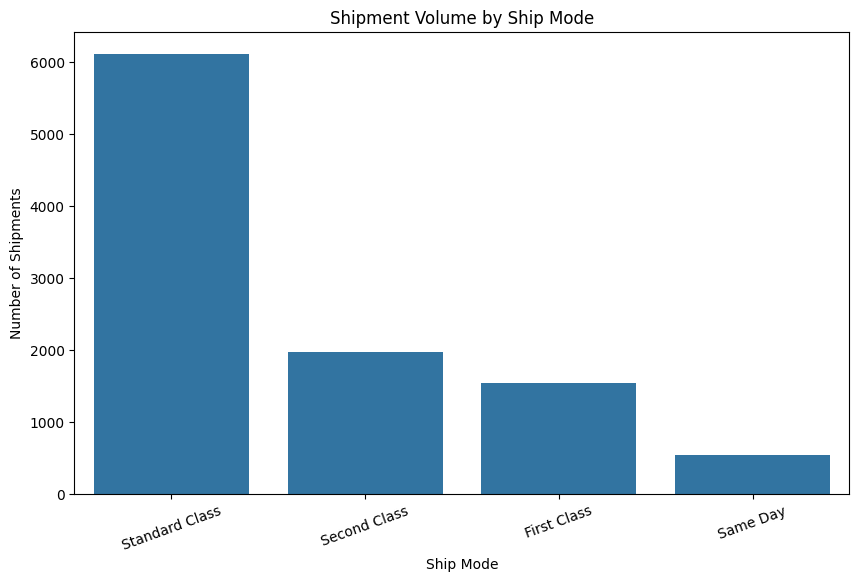

In [50]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Ship Mode",
    order=df["Ship Mode"].value_counts().index
)

plt.title("Shipment Volume by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=20)

plt.show()

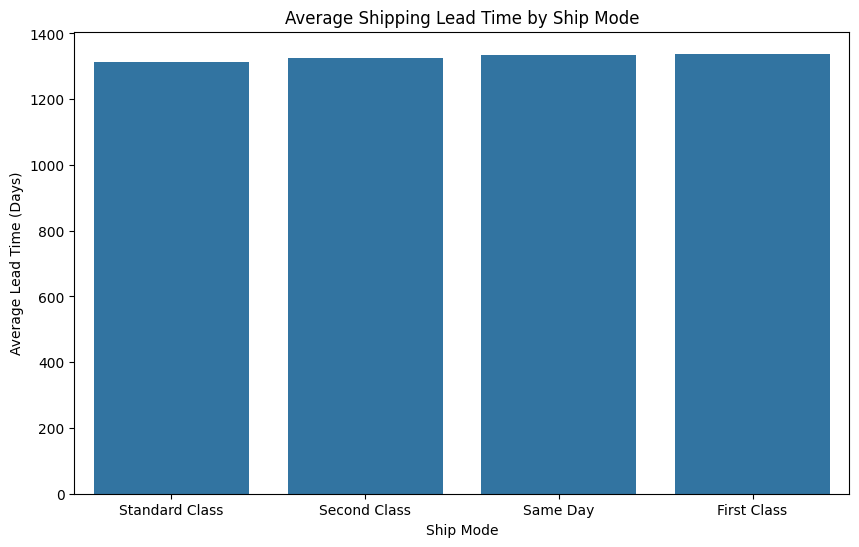

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ship_mode_summary.sort_values(
        "Average_Lead_Time"
    ),
    x="Ship Mode",
    y="Average_Lead_Time"
)

plt.title(
    "Average Shipping Lead Time by Ship Mode"
)

plt.xlabel("Ship Mode")

plt.ylabel(
    "Average Lead Time (Days)"
)

plt.show()

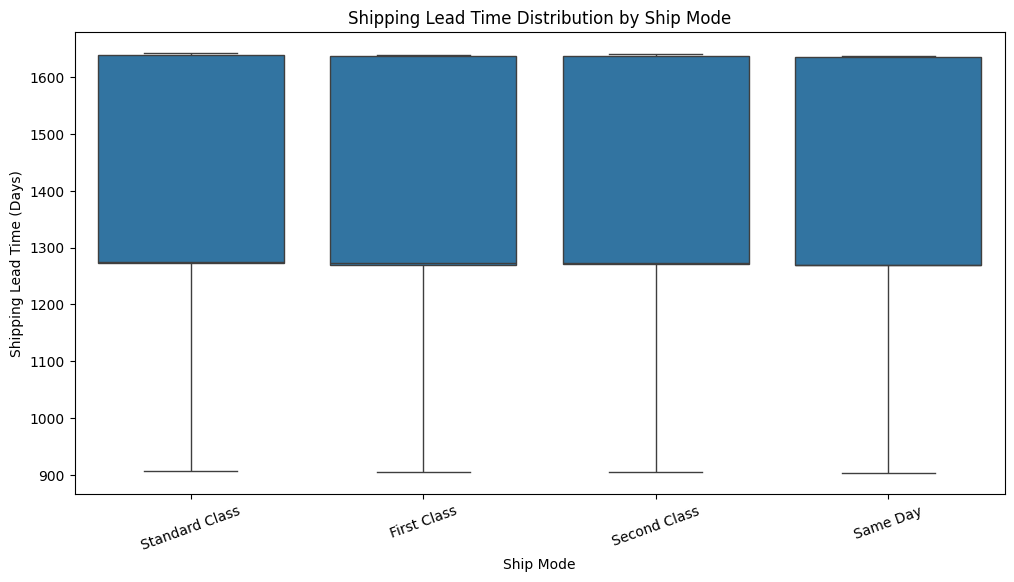

In [52]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Ship Mode",
    y="Shipping Lead Time"
)

plt.title(
    "Shipping Lead Time Distribution by Ship Mode"
)

plt.xlabel("Ship Mode")
plt.ylabel("Shipping Lead Time (Days)")

plt.xticks(rotation=20)

plt.show()

In [53]:
state_summary = (
    df.groupby("State/Province", as_index=False)
      .agg(
          Shipments=("Order ID", "count"),
          Orders=("Order ID", "nunique"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Average_Lead_Time=("Shipping Lead Time", "mean"),
          Median_Lead_Time=("Shipping Lead Time", "median")
      )
)

display(
    state_summary.sort_values(
        "Average_Lead_Time",
        ascending=False
    ).head(20)
)

,State/Province,Shipments,Orders,Sales,Gross_Profit,Average_Lead_Time,Median_Lead_Time
56,West Virginia,4,4,63.97,43.89,1638.000000,1639.0
37,North Dakota,7,5,109.66,73.96,1637.857143,1637.0
47,Saskatchewan,2,2,29.25,18.99,1457.000000,1457.0
20,Manitoba,12,8,138.25,90.27,1455.333333,1455.0
15,Iowa,30,26,400.37,269.97,1443.900000,1636.0
33,New Mexico,37,34,502.71,335.17,1441.837838,1639.0
53,Vermont,11,10,162.44,109.98,1438.909091,1273.0
44,Prince Edward Island,10,8,130.10,88.66,1420.300000,1456.5
49,South Dakota,12,8,151.34,104.14,1395.916667,1640.0
50,Tennessee,183,151,2383.56,1573.52,1391.486339,1276.0


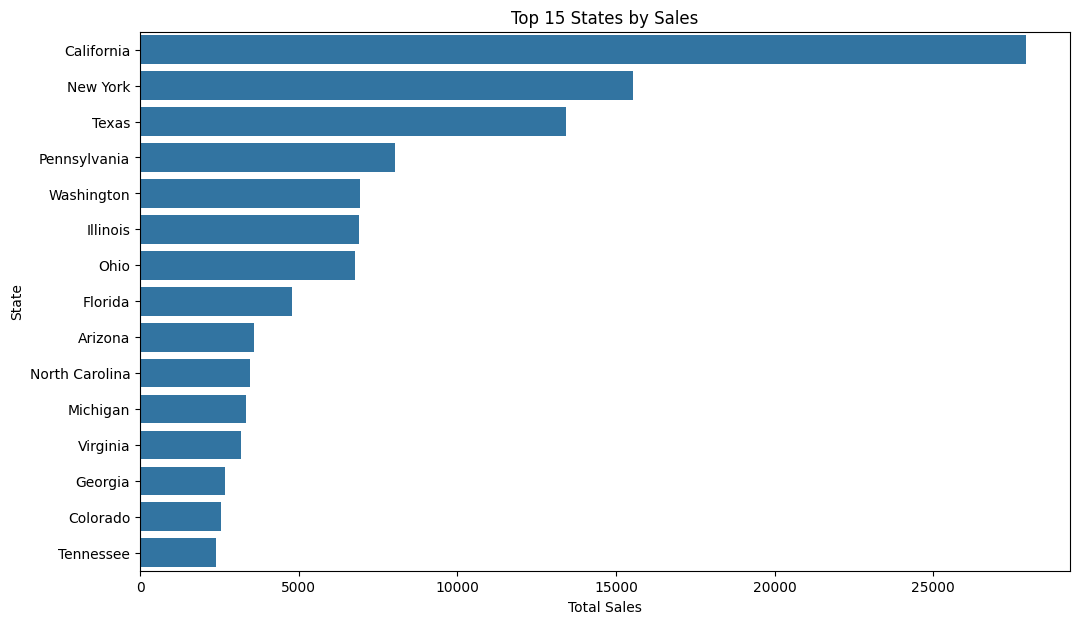

In [54]:
top_sales_states = (
    state_summary
    .sort_values(
        "Sales",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_sales_states,
    x="Sales",
    y="State/Province"
)

plt.title("Top 15 States by Sales")

plt.xlabel("Total Sales")

plt.ylabel("State")

plt.show()

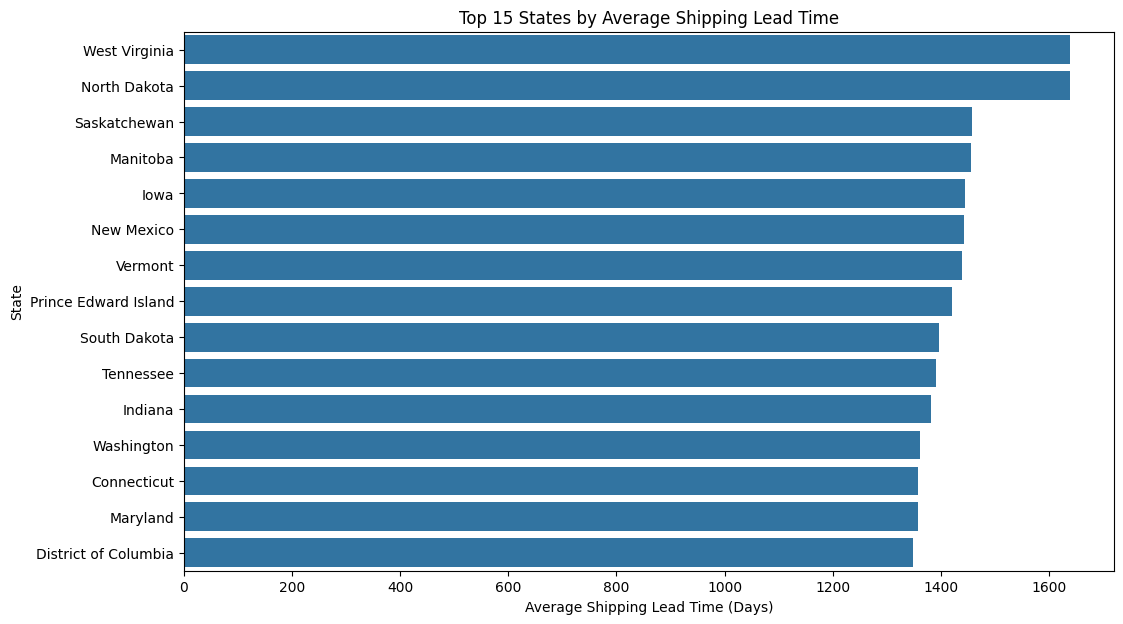

In [55]:
top_delay_states = (
    state_summary
    .sort_values(
        "Average_Lead_Time",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_delay_states,
    x="Average_Lead_Time",
    y="State/Province"
)

plt.title(
    "Top 15 States by Average Shipping Lead Time"
)

plt.xlabel(
    "Average Shipping Lead Time (Days)"
)

plt.ylabel("State")

plt.show()

In [56]:
route_region = (
    df.groupby(
        ["Factory", "Region"],
        as_index=False
    )
    .agg(
        Shipments=("Order ID", "count"),
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Average_Lead_Time=("Shipping Lead Time", "mean"),
        Median_Lead_Time=("Shipping Lead Time", "median"),
        Lead_Time_Std=("Shipping Lead Time", "std")
    )
)

display(
    route_region.sort_values(
        "Average_Lead_Time",
        ascending=False
    )
)

,Factory,Region,Shipments,Orders,Sales,Gross_Profit,Average_Lead_Time,Median_Lead_Time,Lead_Time_Std
11,Sugar Shack,Pacific,3,3,19.24,10.79,1516.666667,1638.0,210.155498
8,Sugar Shack,Atlantic,18,18,118.61,63.81,1375.388889,1275.0,274.606915
4,Secret Factory,Atlantic,72,70,2991.25,1499.85,1349.250000,1275.0,280.717479
5,Secret Factory,Gulf,37,35,930.00,480.00,1332.540541,1274.0,304.830608
19,Wicked Choccy's,Pacific,1342,1123,18525.75,12067.41,1329.101341,1274.0,266.218931
0,Lot's O Nuts,Atlantic,1661,1378,22166.13,15315.63,1326.825406,1274.0,255.990045
18,Wicked Choccy's,Interior,950,802,12419.25,8088.99,1324.551579,1274.0,266.325982
2,Lot's O Nuts,Interior,1321,1113,17856.86,12353.56,1324.196064,1274.0,258.411438
10,Sugar Shack,Interior,8,8,44.74,23.39,1318.625000,1272.5,235.257268
3,Lot's O Nuts,Pacific,1813,1524,24294.04,16788.44,1317.527854,1274.0,266.672700


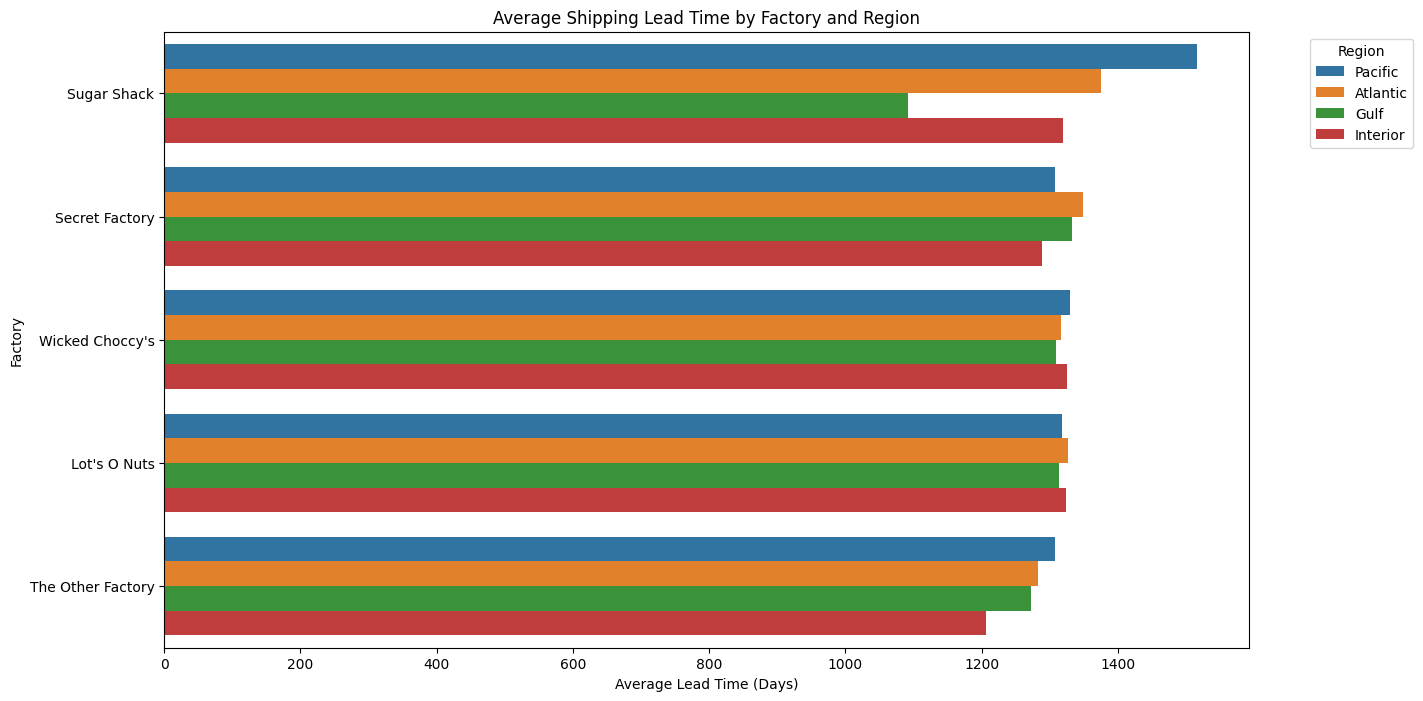

In [57]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=route_region.sort_values(
        "Average_Lead_Time",
        ascending=False
    ),
    x="Average_Lead_Time",
    y="Factory",
    hue="Region"
)

plt.title(
    "Average Shipping Lead Time by Factory and Region"
)

plt.xlabel(
    "Average Lead Time (Days)"
)

plt.ylabel("Factory")

plt.legend(
    title="Region",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

In [58]:
route_state = (
    df.groupby(
        ["Factory", "State/Province"],
        as_index=False
    )
    .agg(
        Shipments=("Order ID", "count"),
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Average_Lead_Time=("Shipping Lead Time", "mean"),
        Median_Lead_Time=("Shipping Lead Time", "median")
    )
)

display(
    route_state.sort_values(
        "Average_Lead_Time",
        ascending=False
    ).head(20)
)

,Factory,State/Province,Shipments,Orders,Sales,Gross_Profit,Average_Lead_Time,Median_Lead_Time
103,Sugar Shack,New Jersey,1,1,5.97,3.72,1642.000000,1642.0
78,Secret Factory,New Hampshire,1,1,6.25,3.25,1641.000000,1641.0
98,Sugar Shack,Connecticut,1,1,3.98,2.48,1641.000000,1641.0
194,Wicked Choccy's,West Virginia,2,2,25.25,16.47,1639.000000,1639.0
37,Lot's O Nuts,North Dakota,5,4,57.16,39.66,1638.200000,1637.0
97,Sugar Shack,California,1,1,6.00,2.80,1638.000000,1638.0
125,The Other Factory,Nevada,1,1,16.25,1.25,1638.000000,1638.0
110,Sugar Shack,Washington,1,1,1.99,1.24,1638.000000,1638.0
63,Secret Factory,Connecticut,1,1,2.50,1.30,1638.000000,1638.0
105,Sugar Shack,Ohio,2,2,18.46,9.86,1637.500000,1637.5


In [59]:
df.to_csv(
    "Nassau_Candy_Cleaned.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

Cleaned dataset saved successfully.


# **Stage 3 : Route Efficiency analysis**

In [60]:
route_analysis = (
    df.groupby(
        ["Factory", "Region"],
        as_index=False
    )
    .agg(
        Shipments=("Order ID", "count"),
        Unique_Orders=("Order ID", "nunique"),
        Total_Units=("Units", "sum"),
        Total_Sales=("Sales", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Profit=("Gross Profit", "sum"),

        Average_Lead_Time=("Shipping Lead Time", "mean"),
        Median_Lead_Time=("Shipping Lead Time", "median"),
        Minimum_Lead_Time=("Shipping Lead Time", "min"),
        Maximum_Lead_Time=("Shipping Lead Time", "max"),
        Lead_Time_Std=("Shipping Lead Time", "std")
    )
)

display(route_analysis)

,Factory,Region,Shipments,Unique_Orders,Total_Units,Total_Sales,Total_Cost,Total_Profit,Average_Lead_Time,Median_Lead_Time,Minimum_Lead_Time,Maximum_Lead_Time,Lead_Time_Std
0,Lot's O Nuts,Atlantic,1661,1378,6214,22166.13,6850.50,15315.63,1326.825406,1274.0,904,1642,255.990045
1,Lot's O Nuts,Gulf,897,745,3373,12023.12,3709.70,8313.42,1313.975474,1274.0,904,1642,266.587905
2,Lot's O Nuts,Interior,1321,1113,5012,17856.86,5503.30,12353.56,1324.196064,1274.0,904,1642,258.411438
3,Lot's O Nuts,Pacific,1813,1524,6813,24294.04,7505.60,16788.44,1317.527854,1274.0,904,1642,266.672700
4,Secret Factory,Atlantic,72,70,308,2991.25,1491.40,1499.85,1349.250000,1275.0,905,1641,280.717479
5,Secret Factory,Gulf,37,35,161,930.00,450.00,480.00,1332.540541,1274.0,906,1642,304.830608
6,Secret Factory,Interior,45,45,186,1590.00,783.20,806.80,1289.088889,1273.0,905,1641,311.225570
7,Secret Factory,Pacific,63,63,229,3076.25,1518.20,1558.05,1307.730159,1274.0,904,1641,276.180178
8,Sugar Shack,Atlantic,18,18,61,118.61,54.80,63.81,1375.388889,1275.0,908,1642,274.606915
9,Sugar Shack,Gulf,4,4,16,38.39,15.15,23.24,1091.250000,1090.5,909,1275,210.447737


In [61]:
route_analysis["Profit Margin %"] = np.where(
    route_analysis["Total_Sales"] != 0,
    (
        route_analysis["Total_Profit"]
        /
        route_analysis["Total_Sales"]
    ) * 100,
    0
)

route_analysis["Profit Margin %"] = (
    route_analysis["Profit Margin %"].round(2)
)

In [62]:
total_route_shipments = route_analysis["Shipments"].sum()

route_analysis["Shipment Share %"] = (
    route_analysis["Shipments"]
    /
    total_route_shipments
    * 100
)

route_analysis["Shipment Share %"] = (
    route_analysis["Shipment Share %"].round(2)
)

In [64]:
min_lead = route_analysis["Average_Lead_Time"].min()
max_lead = route_analysis["Average_Lead_Time"].max()

if max_lead == min_lead:

    route_analysis["Lead Time Efficiency Score"] = 100

else:

    route_analysis["Lead Time Efficiency Score"] = (
        (
            max_lead
            - route_analysis["Average_Lead_Time"]
        )
        /
        (
            max_lead
            - min_lead
        )
        * 100
    )

route_analysis["Lead Time Efficiency Score"] = (
    route_analysis["Lead Time Efficiency Score"]
    .round(2)
)

In [65]:
route_analysis["Lead Time CV %"] = np.where(
    route_analysis["Average_Lead_Time"] != 0,
    (
        route_analysis["Lead_Time_Std"]
        /
        route_analysis["Average_Lead_Time"]
    ) * 100,
    0
)

route_analysis["Lead Time CV %"] = (
    route_analysis["Lead Time CV %"].round(2)
)

In [66]:
delay_threshold = df["Shipping Lead Time"].median()

print(
    f"Delay threshold based on overall median: "
    f"{delay_threshold:.0f} days"
)

Delay threshold based on overall median: 1274 days


In [67]:
df["Delayed"] = (
    df["Shipping Lead Time"]
    > delay_threshold
)

In [68]:
route_delay = (
    df.groupby(
        ["Factory", "Region"],
        as_index=False
    )
    .agg(
        Total_Shipments=("Order ID", "count"),
        Delayed_Shipments=("Delayed", "sum")
    )
)

route_delay["Delay Frequency %"] = (
    route_delay["Delayed_Shipments"]
    /
    route_delay["Total_Shipments"]
    * 100
)

route_delay["Delay Frequency %"] = (
    route_delay["Delay Frequency %"]
    .round(2)
)

display(
    route_delay.sort_values(
        "Delay Frequency %",
        ascending=False
    )
)

,Factory,Region,Total_Shipments,Delayed_Shipments,Delay Frequency %
11,Sugar Shack,Pacific,3,2,66.67
8,Sugar Shack,Atlantic,18,11,61.11
4,Secret Factory,Atlantic,72,37,51.39
5,Secret Factory,Gulf,37,17,45.95
19,Wicked Choccy's,Pacific,1342,600,44.71
18,Wicked Choccy's,Interior,950,416,43.79
15,The Other Factory,Pacific,32,14,43.75
3,Lot's O Nuts,Pacific,1813,780,43.02
6,Secret Factory,Interior,45,19,42.22
13,The Other Factory,Gulf,19,8,42.11


In [69]:
route_analysis = route_analysis.merge(
    route_delay[
        [
            "Factory",
            "Region",
            "Delayed_Shipments",
            "Delay Frequency %"
        ]
    ],
    on=["Factory", "Region"],
    how="left"
)

display(route_analysis)

,Factory,Region,Shipments,Unique_Orders,Total_Units,Total_Sales,Total_Cost,Total_Profit,Average_Lead_Time,Median_Lead_Time,Minimum_Lead_Time,Maximum_Lead_Time,Lead_Time_Std,Profit Margin %,Shipment Share %,Lead Time Efficiency Score,Lead Time CV %,Delayed_Shipments,Delay Frequency %
0,Lot's O Nuts,Atlantic,1661,1378,6214,22166.13,6850.50,15315.63,1326.825406,1274.0,904,1642,255.990045,69.09,16.29,44.62,19.29,687,41.36
1,Lot's O Nuts,Gulf,897,745,3373,12023.12,3709.70,8313.42,1313.975474,1274.0,904,1642,266.587905,69.15,8.80,47.65,20.29,368,41.03
2,Lot's O Nuts,Interior,1321,1113,5012,17856.86,5503.30,12353.56,1324.196064,1274.0,904,1642,258.411438,69.18,12.96,45.24,19.51,542,41.03
3,Lot's O Nuts,Pacific,1813,1524,6813,24294.04,7505.60,16788.44,1317.527854,1274.0,904,1642,266.672700,69.11,17.78,46.81,20.24,780,43.02
4,Secret Factory,Atlantic,72,70,308,2991.25,1491.40,1499.85,1349.250000,1275.0,905,1641,280.717479,50.14,0.71,39.35,20.81,37,51.39
5,Secret Factory,Gulf,37,35,161,930.00,450.00,480.00,1332.540541,1274.0,906,1642,304.830608,51.61,0.36,43.28,22.88,17,45.95
6,Secret Factory,Interior,45,45,186,1590.00,783.20,806.80,1289.088889,1273.0,905,1641,311.225570,50.74,0.44,53.50,24.14,19,42.22
7,Secret Factory,Pacific,63,63,229,3076.25,1518.20,1558.05,1307.730159,1274.0,904,1641,276.180178,50.65,0.62,49.11,21.12,26,41.27
8,Sugar Shack,Atlantic,18,18,61,118.61,54.80,63.81,1375.388889,1275.0,908,1642,274.606915,53.80,0.18,33.21,19.97,11,61.11
9,Sugar Shack,Gulf,4,4,16,38.39,15.15,23.24,1091.250000,1090.5,909,1275,210.447737,60.54,0.04,100.00,19.29,1,25.00


In [70]:
route_analysis["High Volume"] = (
    route_analysis["Shipments"]
    >= route_analysis["Shipments"].median()
)

route_analysis["Long Lead Time"] = (
    route_analysis["Average_Lead_Time"]
    >= route_analysis["Average_Lead_Time"].median()
)

route_analysis["High Delay Frequency"] = (
    route_analysis["Delay Frequency %"]
    >= route_analysis["Delay Frequency %"].median()
)

In [71]:
route_analysis["Investigation Flags"] = (
    route_analysis["High Volume"].astype(int)
    +
    route_analysis["Long Lead Time"].astype(int)
    +
    route_analysis["High Delay Frequency"].astype(int)
)

In [72]:
route_display = route_analysis.sort_values(
    [
        "Investigation Flags",
        "Average_Lead_Time"
    ],
    ascending=[False, False]
)

display(
    route_display[
        [
            "Factory",
            "Region",
            "Shipments",
            "Shipment Share %",
            "Average_Lead_Time",
            "Median_Lead_Time",
            "Lead_Time_Std",
            "Lead Time CV %",
            "Delay Frequency %",
            "Lead Time Efficiency Score",
            "Total_Sales",
            "Total_Profit",
            "Profit Margin %",
            "Investigation Flags"
        ]
    ]
)

,Factory,Region,Shipments,Shipment Share %,Average_Lead_Time,Median_Lead_Time,Lead_Time_Std,Lead Time CV %,Delay Frequency %,Lead Time Efficiency Score,Total_Sales,Total_Profit,Profit Margin %,Investigation Flags
4,Secret Factory,Atlantic,72,0.71,1349.250000,1275.0,280.717479,20.81,51.39,39.35,2991.25,1499.85,50.14,3
19,Wicked Choccy's,Pacific,1342,13.16,1329.101341,1274.0,266.218931,20.03,44.71,44.09,18525.75,12067.41,65.14,3
18,Wicked Choccy's,Interior,950,9.32,1324.551579,1274.0,266.325982,20.11,43.79,45.16,12419.25,8088.99,65.13,3
3,Lot's O Nuts,Pacific,1813,17.78,1317.527854,1274.0,266.672700,20.24,43.02,46.81,24294.04,16788.44,69.11,3
11,Sugar Shack,Pacific,3,0.03,1516.666667,1638.0,210.155498,13.86,66.67,0.00,19.24,10.79,56.08,2
8,Sugar Shack,Atlantic,18,0.18,1375.388889,1275.0,274.606915,19.97,61.11,33.21,118.61,63.81,53.80,2
5,Secret Factory,Gulf,37,0.36,1332.540541,1274.0,304.830608,22.88,45.95,43.28,930.00,480.00,51.61,2
0,Lot's O Nuts,Atlantic,1661,16.29,1326.825406,1274.0,255.990045,19.29,41.36,44.62,22166.13,15315.63,69.09,2
2,Lot's O Nuts,Interior,1321,12.96,1324.196064,1274.0,258.411438,19.51,41.03,45.24,17856.86,12353.56,69.18,2
10,Sugar Shack,Interior,8,0.08,1318.625000,1272.5,235.257268,17.84,25.00,46.55,44.74,23.39,52.28,1


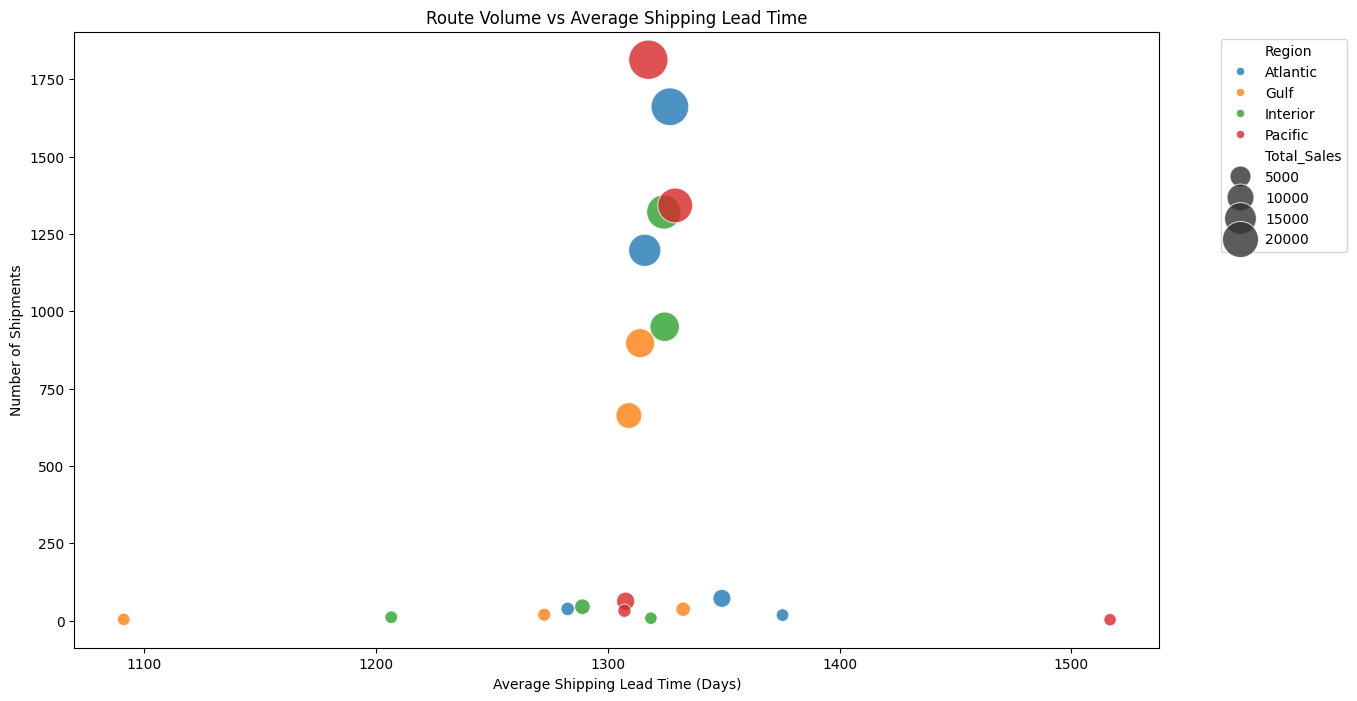

In [73]:
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=route_analysis,
    x="Average_Lead_Time",
    y="Shipments",
    size="Total_Sales",
    hue="Region",
    sizes=(80, 800),
    alpha=0.8
)

plt.title(
    "Route Volume vs Average Shipping Lead Time"
)

plt.xlabel(
    "Average Shipping Lead Time (Days)"
)

plt.ylabel(
    "Number of Shipments"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

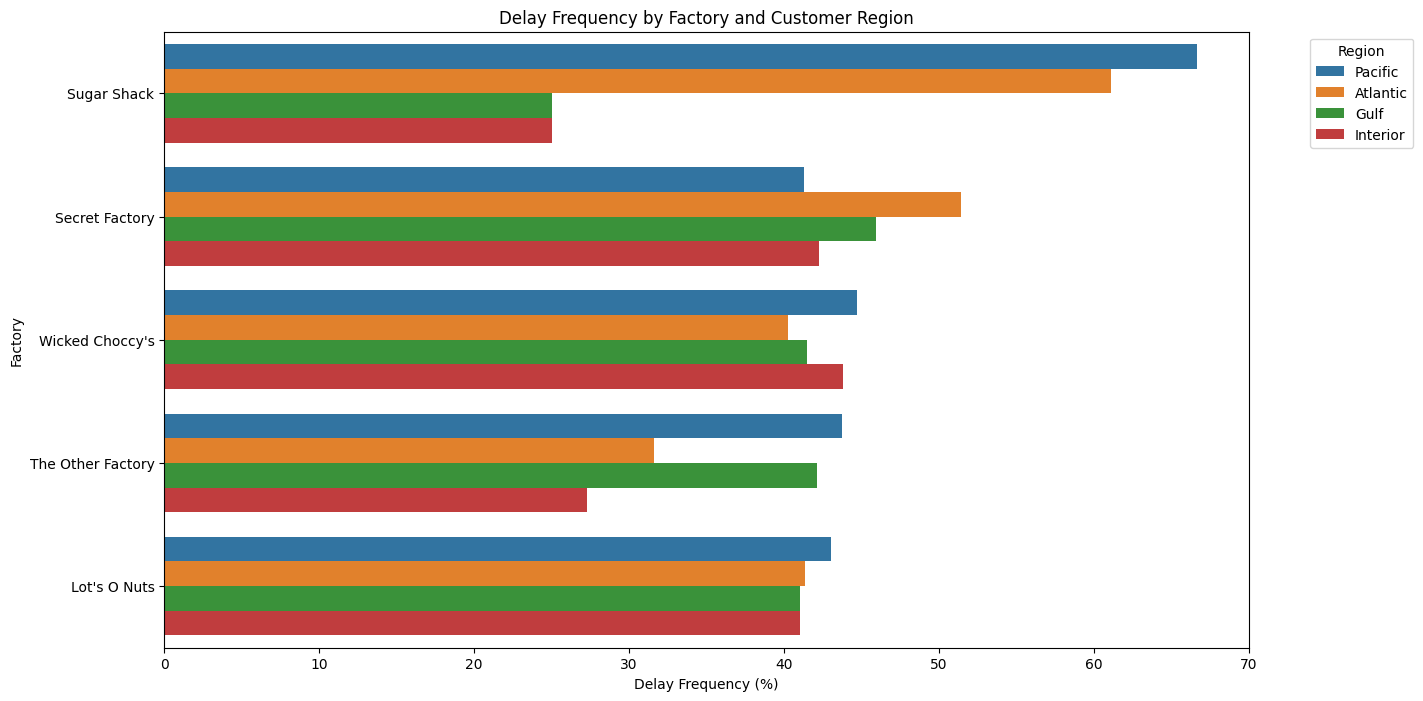

In [74]:
delay_chart = route_analysis.sort_values(
    "Delay Frequency %",
    ascending=False
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=delay_chart,
    x="Delay Frequency %",
    y="Factory",
    hue="Region"
)

plt.title(
    "Delay Frequency by Factory and Customer Region"
)

plt.xlabel(
    "Delay Frequency (%)"
)

plt.ylabel("Factory")

plt.legend(
    title="Region",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

In [75]:
factory_route_analysis = (
    df.groupby(
        "Factory",
        as_index=False
    )
    .agg(
        Shipments=("Order ID", "count"),
        Orders=("Order ID", "nunique"),
        Units=("Units", "sum"),
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Average_Lead_Time=("Shipping Lead Time", "mean"),
        Median_Lead_Time=("Shipping Lead Time", "median"),
        Lead_Time_Std=("Shipping Lead Time", "std"),
        Delayed_Shipments=("Delayed", "sum")
    )
)

factory_route_analysis["Delay Frequency %"] = (
    factory_route_analysis["Delayed_Shipments"]
    /
    factory_route_analysis["Shipments"]
    * 100
)

factory_route_analysis["Profit Margin %"] = (
    factory_route_analysis["Gross_Profit"]
    /
    factory_route_analysis["Sales"]
    * 100
)

display(factory_route_analysis)

,Factory,Shipments,Orders,Units,Sales,Cost,Gross_Profit,Average_Lead_Time,Median_Lead_Time,Lead_Time_Std,Delayed_Shipments,Delay Frequency %,Profit Margin %
0,Lot's O Nuts,5692,4760,21412,76340.15,23569.10,52771.05,1321.228742,1274.0,261.646319,2377,41.760365,69.126207
1,Secret Factory,217,213,884,8587.50,4242.80,4344.70,1321.870968,1274.0,289.077927,99,45.622120,50.593304
2,Sugar Shack,33,33,107,220.98,99.75,121.23,1340.030303,1274.0,265.630557,16,48.484848,54.860168
3,The Other Factory,100,98,388,1282.25,1130.00,152.25,1280.280000,1273.0,259.737633,37,37.000000,11.873660
4,Wicked Choccy's,4152,3445,15863,55352.75,19299.18,36053.57,1321.082129,1274.0,262.166011,1773,42.702312,65.134198


## **Factory volume vs lead time**

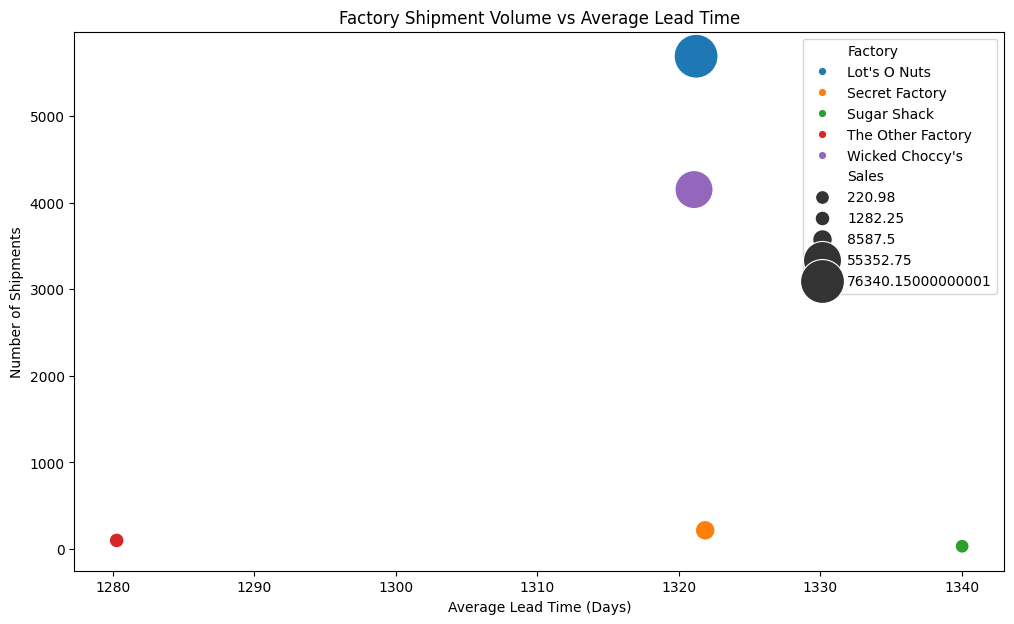

In [76]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=factory_route_analysis,
    x="Average_Lead_Time",
    y="Shipments",
    size="Sales",
    hue="Factory",
    sizes=(100, 1000)
)

plt.title(
    "Factory Shipment Volume vs Average Lead Time"
)

plt.xlabel(
    "Average Lead Time (Days)"
)

plt.ylabel("Number of Shipments")

plt.show()

In [77]:
state_bottlenecks = (
    df.groupby(
        "State/Province",
        as_index=False
    )
    .agg(
        Shipments=("Order ID", "count"),
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Average_Lead_Time=("Shipping Lead Time", "mean"),
        Median_Lead_Time=("Shipping Lead Time", "median"),
        Lead_Time_Std=("Shipping Lead Time", "std"),
        Delayed_Shipments=("Delayed", "sum")
    )
)

state_bottlenecks["Delay Frequency %"] = (
    state_bottlenecks["Delayed_Shipments"]
    /
    state_bottlenecks["Shipments"]
    * 100
)

display(
    state_bottlenecks.sort_values(
        "Average_Lead_Time",
        ascending=False
    ).head(20)
)

,State/Province,Shipments,Orders,Sales,Gross_Profit,Average_Lead_Time,Median_Lead_Time,Lead_Time_Std,Delayed_Shipments,Delay Frequency %
56,West Virginia,4,4,63.97,43.89,1638.000000,1639.0,2.000000,4,100.000000
37,North Dakota,7,5,109.66,73.96,1637.857143,1637.0,1.463850,7,100.000000
47,Saskatchewan,2,2,29.25,18.99,1457.000000,1457.0,258.801082,1,50.000000
20,Manitoba,12,8,138.25,90.27,1455.333333,1455.0,191.139803,6,50.000000
15,Iowa,30,26,400.37,269.97,1443.900000,1636.0,229.801466,18,60.000000
33,New Mexico,37,34,502.71,335.17,1441.837838,1639.0,267.198066,24,64.864865
53,Vermont,11,10,162.44,109.98,1438.909091,1273.0,190.999714,5,45.454545
44,Prince Edward Island,10,8,130.10,88.66,1420.300000,1456.5,255.814190,5,50.000000
49,South Dakota,12,8,151.34,104.14,1395.916667,1640.0,360.350955,8,66.666667
50,Tennessee,183,151,2383.56,1573.52,1391.486339,1276.0,248.201971,101,55.191257


In [78]:
state_bottlenecks["High Volume"] = (
    state_bottlenecks["Shipments"]
    >= state_bottlenecks["Shipments"].median()
)

state_bottlenecks["Long Lead Time"] = (
    state_bottlenecks["Average_Lead_Time"]
    >= state_bottlenecks["Average_Lead_Time"].median()
)

state_bottlenecks["High Delay Frequency"] = (
    state_bottlenecks["Delay Frequency %"]
    >= state_bottlenecks["Delay Frequency %"].median()
)

state_bottlenecks["Investigation Flags"] = (
    state_bottlenecks["High Volume"].astype(int)
    +
    state_bottlenecks["Long Lead Time"].astype(int)
    +
    state_bottlenecks["High Delay Frequency"].astype(int)
)

display(
    state_bottlenecks.sort_values(
        "Investigation Flags",
        ascending=False
    ).head(20)
)

,State/Province,Shipments,Orders,Sales,Gross_Profit,Average_Lead_Time,Median_Lead_Time,Lead_Time_Std,Delayed_Shipments,Delay Frequency %,High Volume,Long Lead Time,High Delay Frequency,Investigation Flags
7,Connecticut,82,74,980.57,653.83,1357.548780,1274.0,271.682874,38,46.341463,True,True,True,3
5,California,2001,1686,27917.40,18479.42,1318.427286,1274.0,264.392878,839,41.929035,True,True,True,3
6,Colorado,182,140,2544.91,1694.63,1337.186813,1274.0,249.676959,78,42.857143,True,True,True,3
21,Maryland,105,80,1476.99,997.57,1356.780952,1274.0,238.897708,44,41.904762,True,True,True,3
17,Kentucky,139,112,1880.63,1242.37,1328.446043,1274.0,274.445717,67,48.201439,True,True,True,3
26,Missouri,66,56,882.83,595.41,1339.863636,1274.0,278.414792,29,43.939394,True,True,True,3
24,Minnesota,89,75,1161.46,779.28,1335.471910,1275.0,297.651913,47,52.808989,True,True,True,3
14,Indiana,149,123,2002.78,1343.44,1381.496644,1274.0,242.353763,74,49.664430,True,True,True,3
11,Georgia,184,151,2692.84,1751.32,1338.635870,1274.0,249.182868,83,45.108696,True,True,True,3
36,North Carolina,249,216,3450.86,2331.16,1334.883534,1274.0,254.989434,111,44.578313,True,True,True,3


In [79]:
route_analysis.to_csv(
    "Route_Analysis.csv",
    index=False
)

factory_route_analysis.to_csv(
    "Factory_Analysis.csv",
    index=False
)

state_bottlenecks.to_csv(
    "State_Bottleneck_Analysis.csv",
    index=False
)

print("Analysis files saved successfully.")

Analysis files saved successfully.


# Project level summary

In [80]:
summary = {
    "Total Records": len(df),
    "Unique Orders": df["Order ID"].nunique(),
    "Total Sales": df["Sales"].sum(),
    "Total Gross Profit": df["Gross Profit"].sum(),
    "Average Lead Time": df["Shipping Lead Time"].mean(),
    "Median Lead Time": df["Shipping Lead Time"].median(),
    "Number of Factories": df["Factory"].nunique(),
    "Number of Regions": df["Region"].nunique(),
    "Number of States": df["State/Province"].nunique(),
    "Number of Ship Modes": df["Ship Mode"].nunique(),
    "Delay Threshold": delay_threshold
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Total Records,10194.000000
1,Unique Orders,8549.000000
2,Total Sales,141783.630000
3,Total Gross Profit,93442.800000
4,Average Lead Time,1320.841868
5,Median Lead Time,1274.000000
6,Number of Factories,5.000000
7,Number of Regions,4.000000
8,Number of States,59.000000
9,Number of Ship Modes,4.000000
